# OpenPyTEA — Tutorial 3: Performing Analysis

OpenPyTEA provides four core analysis tools that build on a configured `Plant` model:

| Analysis | Functions | What it answers |
|---|---|---|
| Cost breakdown | `direct_costs_data`, `fixed_capital_data`, `variable_opex_data`, `fixed_opex_data` | *Where does the money go?* |
| Sensitivity | `sensitivity_data` + `plot_sensitivity` | *How does one parameter change the result?* |
| Tornado | `tornado_data` + `plot_tornado` | *Which parameter matters most?* |
| Monte Carlo | `monte_carlo` + `plot_monte_carlo` | *What is the probability distribution of outcomes?* |

All analysis functions that accept a `plants` argument can take **one or more `Plant` objects** — making it straightforward to compare configurations side by side. In this tutorial, we compare **three imaginary methanol production routes**, each with a different process configuration, feedstock mix, and byproduct slate, at the same production capacity.

---

## Setup — Three Methanol Production Routes

We define three plants that all produce **70 TPD of methanol** at the same selling price, economic parameters, and project lifetime. Each route has a different feedstock, equipment set, and set of byproducts.

| Plant | Route | Main feedstock | Byproducts | Process type |
|---|---|---|---|---|
| Plant 1 | Natural gas reforming (SMR) | Natural gas | CO₂ (sold as by-product) | Fluids |
| Plant 2 | Biomass gasification | Biomass | Electricity export | Mixed |
| Plant 3 | Power-to-methanol (electrolysis) | Electricity + water | Oxygen | Fluids |

In [ ]:
from openpytea import *

### Plant 1 — Natural Gas Reforming (SMR)

Steam methane reforming at commercial scale. CO₂ separated from the product stream is captured and sold as a by-product.

In [ ]:
comp_p1 = Equipment(
    name="COMP-1",   param=500,  process_type="Fluids",
    category="Compressors, fans, & blowers", type="Compressor, centrifugal",
)
hx_p1 = Equipment(
    name="HX-1",     param=30,    process_type="Fluids",
    category="Heat Exchangers",              type="U-tube shell & tube",
    material="304 stainless steel",
)
reactor_p1 = Equipment(
    name="REACT-1",  param=0,      process_type="Fluids", category="Reactors",
    purchased_cost=10_000_000,     cost_year=2021,
)
pump_p1 = Equipment(
    name="PUMP-1",   param=75,     process_type="Fluids",
    category="Pumps",                        type="Centrifugal",
)
separator_p1 = Equipment(
    name="SEP-1",    param=0,      process_type="Fluids", category="Vessels & tanks",
    purchased_cost=1_500_000,      cost_year=2021,
)

### Plant 2 — Biomass Gasification

Biomass is gasified to syngas, cleaned, and converted to methanol. Surplus steam drives a turbine that exports electricity to the grid as a by-product.

In [ ]:
gasifier_p2 = Equipment(
    name="GASI-1",   param=0,      process_type="Mixed", category="Reactors",
    purchased_cost=7_000_000,     cost_year=2021,
)
scrubber_p2 = Equipment(
    name="SCRUB-1",  param=0,      process_type="Mixed", category="Vessels & tanks",
    purchased_cost=1_500_000,      cost_year=2021,
)
hx_p2 = Equipment(
    name="HX-2",     param=90,    process_type="Fluids",
    category="Heat Exchangers",              type="U-tube shell & tube",
    material="Carbon steel",
)
comp_p2 = Equipment(
    name="COMP-2",   param=600,  process_type="Fluids",
    category="Compressors, fans, & blowers", type="Compressor, centrifugal",
)
reactor_p2 = Equipment(
    name="REACT-2",  param=0,      process_type="Fluids", category="Reactors",
    purchased_cost=3_000_000,     cost_year=2021,
)
turbine_p2 = Equipment(
    name="TURB-1",   param=0,      process_type="Fluids", category="Turbines",
    purchased_cost=2_000_000,      cost_year=2021,
)

### Plant 3 — Power-to-Methanol (Electrolysis)

Water is electrolysed to produce hydrogen; CO₂ is sourced externally. Oxygen produced in the electrolyser is sold as a by-product. No combustion feedstock.

In [ ]:
electrolyser_p3 = Equipment(
    name="ELEC-1",   param=0,      process_type="Fluids", category="Reactors",
    purchased_cost=15_000_000,     cost_year=2022,
)
comp_p3 = Equipment(
    name="COMP-3",   param=550,  process_type="Fluids",
    category="Compressors, fans, & blowers", type="Compressor, centrifugal",
)
reactor_p3 = Equipment(
    name="REACT-3",  param=0,      process_type="Fluids", category="Reactors",
    purchased_cost=7_500_000,     cost_year=2022,
)
separator_p3 = Equipment(
    name="SEP-2",    param=0,      process_type="Fluids", category="Vessels & tanks",
    purchased_cost=2_500_000,      cost_year=2022,
)

### Plant Configurations

All three plants share the same economic parameters and methanol production capacity of 70,000 kg/day at a selling price of 2.00 USD/kg.

In [ ]:
common = {
    "interest_rate":     0.08,
    "project_lifetime":  20,
    "plant_utilization": 0.90,
    "tax_rate":          0.25,
    "operator_hourly_rate": {"rate": 38.0},
    "depreciation": {
        "method": "straight_line", "life": 12,
        "salvage_fraction": 0.05, "service_start_year": 2,
    },
}

# ── Plant 1: SMR ──────────────────────────────────────────────────────────────
config_p1 = {
    **common,
    "plant_name":   "SMR",
    "process_type": "Fluids",
    "equipment":    [comp_p1, hx_p1, reactor_p1, pump_p1, separator_p1],
    "plant_products": {
        "methanol":       {"production": 70_000, "price": 2.00},  # kg/day, USD/kg
        "carbon_dioxide": {"production": 29_000, "price": 0.30},  # kg/day — by-product
    },
    "variable_opex_inputs": {
        "natural_gas":   {"consumption": 35_000, "price": 0.35},  # kg/day
        "electricity":   {"consumption": 14_000, "price": 0.08},  # kWh/day
        "process_water": {"consumption": 20_000, "price": 0.002}, # kg/day
    },
}

plant1 = Plant(config_p1); plant1.calculate_all()

# ── Plant 2: Biomass gasification ─────────────────────────────────────────────
config_p2 = {
    **common,
    "plant_name":   "Biomass",
    "process_type": "Mixed",
    "equipment":    [gasifier_p2, scrubber_p2, hx_p2, comp_p2, reactor_p2, turbine_p2],
    "plant_products": {
        "methanol":    {"production": 70_000, "price": 2.00},     # kg/day
        "electricity": {"production":  6_500, "price": 0.08},     # kWh/day — exported
    },
    "variable_opex_inputs": {
        "biomass":       {"consumption":  60_000, "price": 0.04}, # kg/day
        "electricity":   {"consumption":  9_800, "price": 0.08}, # kWh/day (net import)
        "process_water": {"consumption":  22_000, "price": 0.002},# kg/day
    },
}

plant2 = Plant(config_p2); plant2.calculate_all()

# ── Plant 3: Power-to-methanol ────────────────────────────────────────────────
config_p3 = {
    **common,
    "plant_name":   "PtM",
    "process_type": "Fluids",
    "equipment":    [electrolyser_p3, comp_p3, reactor_p3, separator_p3],
    "plant_products": {
        "methanol":  {"production": 70_000, "price": 2.00},       # kg/day
        "oxygen":    {"production": 40_000, "price": 0.20},       # kg/day — by-product
    },
    "variable_opex_inputs": {
        "electricity":   {"consumption": 200_000, "price": 0.05}, # kWh/day — dominant
        "process_water": {"consumption":  40_000, "price": 0.002},# kg/day
        "co2_feedstock": {"consumption":  60_000, "price": 0.03}, # kg/day — captured CO2
    },
}

plant3 = Plant(config_p3); plant3.calculate_all()

for p in [plant1, plant2, plant3]:
    print(f"{p.name:<8} | FCI: ${p.fixed_capital:>14,.0f} | LCOP: ${p.levelized_cost:.3f}/kg | NPV: ${p.npv:>14,.0f}")

## 1. Cost Breakdown Analysis

Stacked bar charts show where the capital and operating costs originate. Each `*_data()` function accepts a list of one or more `Plant` objects.

The `pct=True` argument switches from absolute values to percentage shares — useful for comparing cost structures when plants have very different absolute scales.

### Analysis functions and plotting functions

Each analysis tool in OpenPyTEA is split into two separate functions: a **data function** and a **plotting function**.

| Function type | What it does | Output |
|---|---|---|
| `*_data()` | Runs the analysis, collects and structures results | A Python dictionary |
| `plot_*()` | Takes that dictionary and renders a chart | A matplotlib `Axes` object |

This separation is intentional — it gives you full flexibility:

- **Inspect the raw data** before plotting — useful for debugging or exporting results to a table
- **Pass the data to your own plotting code** if you need a different chart style or want to embed results in a report
- **Combine data from multiple runs** before visualising

The cell below shows what `direct_costs_data()` actually returns before it is passed to `plot_stacked_bar()`.

In [ ]:
# Inspect the raw output of a data function before plotting
data = direct_costs_data([plant1])

# 'data' is a dictionary — keys are plant names, values are dicts of cost components
print(type(data))
print("\nKeys:", list(data.keys()))
data

# Pass to plot_stacked_bar when ready
plot_stacked_bar(data)

### 1a. Equipment Direct Costs

In [ ]:
# Percentage share — normalises each plant to 100 % so the composition is directly comparable
plot_stacked_bar(direct_costs_data([plant2], pct=True))

### 1b. Fixed Capital Breakdown

Plant 2 (Mixed process type) carries higher OSBL and contingency factors relative to its ISBL.

In [ ]:
plot_stacked_bar(fixed_capital_data([plant1, plant2, plant3]))

In [ ]:
plot_stacked_bar(fixed_capital_data([plant1, plant2, plant3], pct=True))

### 1c. Variable OPEX Breakdown

The three routes have completely different input profiles. The absolute chart shows the scale difference; `pct=True` reveals each route's feedstock dependency structure.

In [ ]:
# Absolute — Plant 3 electricity cost is substantial at scale
plot_stacked_bar(variable_opex_data([plant1, plant2, plant3]))

In [ ]:
# Percentage — natural gas dominates Plant 1; biomass dominates Plant 2; electricity dominates Plant 3
plot_stacked_bar(variable_opex_data([plant1, plant2, plant3], pct=True))

### 1d. Fixed OPEX Breakdown

In [ ]:
plot_stacked_bar(fixed_opex_data([plant1, plant2, plant3]))

## 2. Single-Parameter Sensitivity Analysis

`sensitivity_data()` varies one parameter across a ± range and evaluates a chosen financial metric at each point.

| Argument | Description |
|---|---|
| `plants` | One or more `Plant` objects |
| `parameter` | Top-level config key, or shorthand for a product/OPEX price |
| `plus_minus_value` | Fractional variation from baseline (e.g. `0.5` = ±50 %) |
| `n_points` | Number of evaluation points |
| `metric` | `"LCOP"`, `"NPV"`, `"ROI"`, `"IRR"`, or `"PBT"` |

### 2a. Discount rate vs NPV — all three plants

A shared parameter — the capital-intensive Plant 3 (electrolyser) is most sensitive because it carries the highest FCI.

In [ ]:
plot_sensitivity(sensitivity_data(
    plants=[plant1, plant2, plant3],
    parameter="interest_rate",
    plus_minus_value=0.5, n_points=31, metric="NPV",
))

### 2b. Electricity price vs LCOP — all three plants

All three plants consume electricity, but Plant 3 is far more exposed — electricity is its dominant feedstock. This single chart captures the key differentiation between routes.

In [ ]:
plot_sensitivity(sensitivity_data(
    plants=[plant1, plant2, plant3],
    parameter="variable_opex_inputs.electricity",
    plus_minus_value=0.5, n_points=31, metric="LCOP",
))

### 2c. Methanol price vs LCOP — Plant 1 only

A single-plant sensitivity to show the break-even product price — the point where LCOP equals the methanol selling price.

In [ ]:
plot_sensitivity(sensitivity_data(
    plants=[plant1],
    parameter="methanol",
    plus_minus_value=0.5, n_points=31, metric="PBT",
))

## 3. Tornado Diagram

`tornado_data()` runs a sensitivity for **all** variable parameters simultaneously and ranks them by their impact on the chosen metric. It takes a single `Plant` — we run it for Plant 1 for the LCOP and NPV metrics.

In [ ]:
# Plant 1 — SMR (LCOP)
plot_tornado(tornado_data(plant=plant1, plus_minus_value=0.20, metric="LCOP"))

In [ ]:
# Plant 1 — SMR (NPV)
plot_tornado(tornado_data(plant=plant1, plus_minus_value=0.20, metric="NPV"))

## 4. Monte Carlo Simulation

`monte_carlo()` samples all uncertain parameters simultaneously from **truncated-normal distributions** and computes the financial metrics for each sample set.

### 4a. Defining uncertainty inputs

For **prices** (product prices, feedstock/utility prices, and labour rate), add `std`, `min`, and `max` alongside the baseline value:

| Field | Description |
|---|---|
| `std` | Standard deviation of the truncated-normal distribution |
| `min` | Lower bound |
| `max` | Upper bound |

For **structural project parameters**, use `project_uncertainties`:

```python
"project_uncertainties": {
    "fixed_capital_factor": {"std": 0.25, "min": 0.60, "max": 1.50},
    "interest_rate":        {"std": 0.03, "min": 0.04, "max": 0.15},
    "plant_utilization":    {"std": 0.05, "min": 0.70, "max": 1.00},
    "fixed_opex_factor":    {"std": 0.00},
    "project_lifetime":     {"std": 0.00},
    "tax_rate":             {"std": 0.00},
}
```

`fixed_capital_factor` is a multiplier on the total FCI — it captures overall capital cost uncertainty without assigning distributions to individual equipment items.

> **Note:** Use `num_samples=1_000_000` for publication-quality results. The 10,000-sample run below runs quickly for demonstration purposes.

In [ ]:
# Shared uncertainty settings — applied to all three plants
shared_unc = {
    "operator_hourly_rate": {"rate": 38.0, "std": 8.0, "min": 25.0, "max": 55.0},
    "project_uncertainties": {
        "fixed_capital_factor": {"std": 0.25, "min": 0.60, "max": 1.50},
        "interest_rate":        {"std": 0.03, "min": 0.04, "max": 0.15},
        "plant_utilization":    {"std": 0.05, "min": 0.70, "max": 1.00},
        "fixed_opex_factor":    {"std": 0.00},
        "project_lifetime":     {"std": 0.00},
        "tax_rate":             {"std": 0.00},
    },
}

# Plant 1 MC — natural gas price is the key stochastic input
config_p1_mc = {
    **config_p1,
    **shared_unc,
    "plant_products": {
        "methanol":       {"production": 70_000, "price": 2.00, "std": 0.30, "min": 1.20, "max": 2.80},
        "carbon_dioxide": {"production": 29_000, "price": 0.30, "std": 0.10, "min": 0.10, "max": 0.50},
    },
    "variable_opex_inputs": {
        "natural_gas":   {"consumption": 35_000, "price": 0.35, "std": 0.10, "min": 0.15, "max": 0.60},
        "electricity":   {"consumption": 14_000, "price": 0.08, "std": 0.02, "min": 0.04, "max": 0.15},
        "process_water": {"consumption": 20_000, "price": 0.002,"std": 0.001,"min": 0.001,"max": 0.005},
    },
}

# Plant 2 MC — biomass price and electricity export price are the key stochastic inputs
config_p2_mc = {
    **config_p2,
    **shared_unc,
    "plant_products": {
        "methanol":    {"production": 70_000, "price": 2.00, "std": 0.30, "min": 1.20, "max": 2.80},
        "electricity": {"production":  6_500, "price": 0.08, "std": 0.02, "min": 0.04, "max": 0.15},
    },
    "variable_opex_inputs": {
        "biomass":       {"consumption":  60_000, "price": 0.04, "std": 0.015,"min": 0.02, "max": 0.09},
        "electricity":   {"consumption":   9_800, "price": 0.08, "std": 0.02, "min": 0.04, "max": 0.15},
        "process_water": {"consumption":  22_000, "price": 0.002,"std": 0.001,"min": 0.001,"max": 0.005},
    },
}

# Plant 3 MC — electricity price is the dominant stochastic risk
config_p3_mc = {
    **config_p3,
    **shared_unc,
    "plant_products": {
        "methanol": {"production": 70_000, "price": 2.00, "std": 0.30, "min": 1.20, "max": 2.80},
        "oxygen":   {"production": 40_000, "price": 0.20, "std": 0.05, "min": 0.08, "max": 0.35},
    },
    "variable_opex_inputs": {
        "electricity":   {"consumption": 200_000, "price": 0.05, "std": 0.02, "min": 0.02, "max": 0.12},
        "process_water": {"consumption":  40_000, "price": 0.002,"std": 0.001,"min": 0.001,"max": 0.005},
        "co2_feedstock": {"consumption":  60_000, "price": 0.03, "std": 0.01, "min": 0.01, "max": 0.08},
    },
}

plant1_mc = Plant(config_p1_mc); plant1_mc.calculate_all()
plant2_mc = Plant(config_p2_mc); plant2_mc.calculate_all()
plant3_mc = Plant(config_p3_mc); plant3_mc.calculate_all()

### 4b. Run and plot results

We run the simulation for all three plants and compare their LCOP and NPV distributions. Plant 2 (biomass) sits between Plant 1 (SMR) and Plant 3 (PtM) in terms of cost level; Plant 3 is expected to show the widest distribution due to its high electricity price exposure.

In [ ]:
import numpy as np

mc1 = monte_carlo(plant=plant1_mc, num_samples=10_000, batch_size=1_000)
mc2 = monte_carlo(plant=plant2_mc, num_samples=10_000, batch_size=1_000)
mc3 = monte_carlo(plant=plant3_mc, num_samples=10_000, batch_size=1_000)

In [ ]:
# LCOP distributions — all three routes
plot_monte_carlo(plant1_mc, metric="LCOP")

In [ ]:
# ROI distributions — Plant 2 sits between SMR and PtM in spread
plot_monte_carlo(plant2_mc, metric="ROI")

### 4c. Comparing distributions across routes

`plot_multiple_monte_carlo()` overlays all three LCOP distributions on a single axes — making it easy to compare the spread and central tendency of each route at a glance.

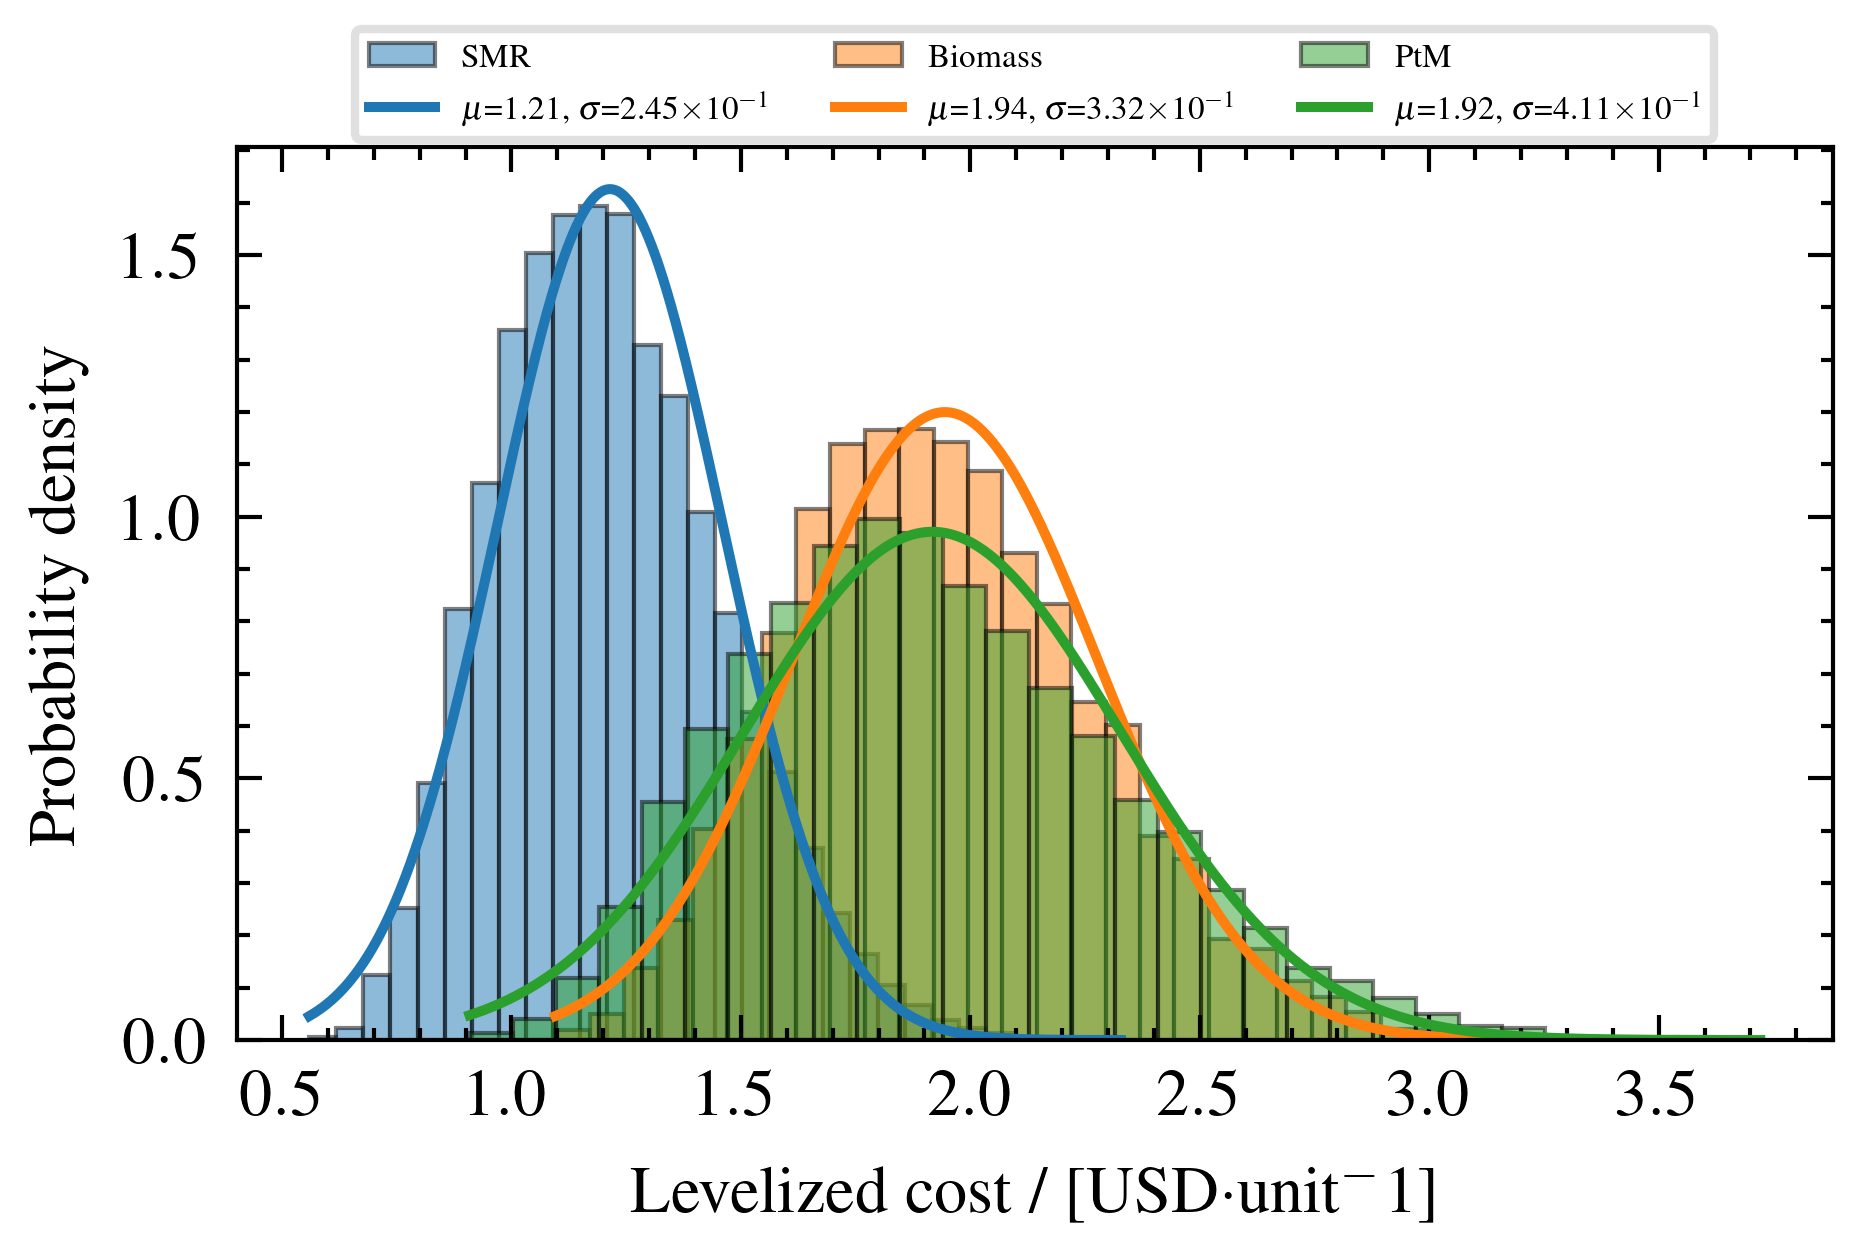

<Axes: xlabel='Levelized cost / [USD$\\cdot$unit$^-1$]', ylabel='Probability density'>

In [34]:
plot_multiple_monte_carlo([plant1_mc, plant2_mc, plant3_mc], metric="LCOP")

In [35]:
# Summary statistics — P10 / P50 / P90 comparison across all three routes
def print_stats(mc, label):
    lcop = mc["metrics"]["LCOP"]
    npv  = mc["metrics"]["NPV"]
    print(f"{label}")
    print(f"  LCOP  P10/P50/P90 : ${np.percentile(lcop,10):.3f} / ${np.percentile(lcop,50):.3f} / ${np.percentile(lcop,90):.3f}  per kg")
    print(f"  NPV   P10/P50/P90 : ${np.percentile(npv,10):>14,.0f} / ${np.percentile(npv,50):>14,.0f} / ${np.percentile(npv,90):>14,.0f}")
    print(f"  P(NPV > 0)        : {(npv > 0).mean()*100:.1f} %\n")

print_stats(mc1, "Plant 1 — SMR")
print_stats(mc2, "Plant 2 — Biomass")
print_stats(mc3, "Plant 3 — PtM")

Plant 1 — SMR
  LCOP  P10/P50/P90 : $0.911 / $1.196 / $1.545  per kg
  NPV   P10/P50/P90 : $    16,945,661 / $    87,748,331 / $   182,048,024
  P(NPV > 0)        : 95.0 %

Plant 2 — Biomass
  LCOP  P10/P50/P90 : $1.536 / $1.919 / $2.386  per kg
  NPV   P10/P50/P90 : $   -82,456,265 / $   -12,130,196 / $    73,001,368
  P(NPV > 0)        : 41.8 %

Plant 3 — PtM
  LCOP  P10/P50/P90 : $1.411 / $1.880 / $2.473  per kg
  NPV   P10/P50/P90 : $   -90,163,879 / $   -10,013,545 / $    88,927,866
  P(NPV > 0)        : 44.5 %



## Summary

| Tool | Functions | Answers |
|---|---|---|
| Cost breakdown | `direct_costs_data`, `fixed_capital_data`, `variable_opex_data`, `fixed_opex_data` | *Where does cost come from?* |
| Sensitivity | `sensitivity_data` + `plot_sensitivity` | *How sensitive is the result to one parameter?* |
| Tornado | `tornado_data` + `plot_tornado` | *Which parameter matters most?* |
| Monte Carlo | `monte_carlo` + `plot_monte_carlo` | *What is the range of possible outcomes?* |

Key things demonstrated in this tutorial:

- `pct=True` in `plot_stacked_bar()` normalises bars to 100 % — useful when absolute scales differ between plants
- Passing multiple plants to analysis functions produces direct side-by-side comparisons
- `tornado_data()` takes a single plant — run it separately per route to compare cost driver rankings
- Plant 3 (PtM) shows a wider LCOP and NPV distribution than Plant 1 (SMR), reflecting its higher sensitivity to electricity price uncertainty

These three tutorials represent the full OpenPyTEA workflow:

1. **Tutorial 1** — Define equipment (cost estimation and factors)
2. **Tutorial 2** — Configure and build a `Plant` (CAPEX, OPEX, financial metrics)
3. **Tutorial 3** — Analyse and visualise results (sensitivity, tornado, Monte Carlo)

For more complex real-world examples, see the **case study notebooks** in this same folder.